# Initialization

Checking the version of Python installed. The next steps will be to:

*   import libraries
*   determine functions/classes (if needed)
*   create list of URLs.

So let's begin!

In [1]:
!python --version
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import csv

Python 3.9.25


We will save our datasets in the folder `./datasets`.

In [2]:
!rm -rf ./datasets
!mkdir ./datasets

Let's create a **list** where we will insert direct URLs for downloading csv files from `opendata.az`

In [3]:
### URLs can be inserted directly for the installation ###

### ToC

# 0 # NO DATA ON THE 0-th INDEX!
# 1 # Nəqliyyat sektorunda sərnişin daşınmasından əldə olunan gəlir ('https://opendata.az/@dsk/revenue-from-passenger-transportation-in-the-transportation-sector')
# 2 # Nəqliyyat sektorunda əlaqə növləri üzrə sərnişin daşınması, min sərnişin. ('https://opendata.az/@dsk/neqliyyat-sektorunda-elaqe-novleri-uzre-sernisin-dasinmasi-statistikasi')
# 3 # Nəqliyyat üzrə əsas makro göstəricilər ('https://opendata.az/@dsk/key-macro-indicators-for-transport')
# 4 # Nəqliyyat sektorunda 1 sərnişinin orta daşınma məsafəsi ('https://opendata.az/@dsk/average-transportation-distance-of-1-passenger-in-the-transport-sector/r/c488a8eb-bfe2-42ea-8a31-894e38492345')
# 5 # Boru kəməri nəqliyyatı üzrə əsas göstəricilər (natura ifadəsində) ('https://opendata.az/@dsk/boru-kemeri-neqliyyati-ile-bagli-statistik-gostericiler/r/d687598e-1c24-4621-8818-e5dd4a059412')

opendataurls = [None, 'https://admin.opendata.az/dataset/1cb0a662-8737-45c2-a3f8-c8fa21888a1a/resource/d51060b9-27cf-4dab-b2b2-4397b33371af/download/nqliyyat-sektorunda-srniin-danmasndan-ld-olunan-glir-min-manat-dt_bj_029.csv',
                'https://admin.opendata.az/dataset/467cbf09-b828-47f7-acb1-befdba793435/resource/059d5f88-9b3b-42f5-ab08-b2b4525ed687/download/nqliyyat-sektorunda-laq-novlri-uzr-srniin-danmas-min-srniin-dt_bj_021.csv',
                'https://admin.opendata.az/dataset/2bf54269-fa55-4b9a-859b-2bd06c74f3d6/resource/1fe4226b-f616-4c95-8aa7-f7f62b9eb404/download/nqliyyat-uzr-sas-makro-gostricilr-dt_bj_002.csv',
                'https://admin.opendata.az/dataset/f3d36c3a-8bdc-4ceb-9bd5-2c73d2db2d8d/resource/c488a8eb-bfe2-42ea-8a31-894e38492345/download/nqliyyat-sektorunda-1-srniinin-orta-danma-msafsi-dt_bj_050.csv',
                'https://admin.opendata.az/dataset/4b62b286-efa5-455f-8b04-dadbf5ae2c23/resource/d687598e-1c24-4621-8818-e5dd4a059412/download/boru-kmri-nqliyyat-uzr-sas-gostricilr-natura-ifadsind-dt_bj_051.csv',
                ]

Creating 3 functions as:

1.   **downloadf** -> Download spesific dataset from the list `opendataurls` by their defined index.
2.   **loadf** -> it will be used to read csv files, converting them into pandas format. We will use `csv.sniffer` to determine delimiter.
3.   **sniffer** -> that will be used by `loadf` function

In [4]:
def loadf(index, bytes_to_sniff=4096, encoding='utf-8'):
  path = f'./datasets/data{index}.csv'
  return pd.read_csv(path, sep=sniffer(path, bytes_to_sniff, encoding))

def sniffer(file_path, bytes_to_sniff=4096, encoding='utf-8'):
    with open(file_path, 'r', newline='', encoding=encoding) as file:
        return csv.Sniffer().sniff(file.read(bytes_to_sniff)).delimiter

def downloadf(index):
    !wget -q --show-progress "{opendataurls[index]}" -O "./datasets/data{index}.csv"

Use the below to automatically download and load all the datasets defined in `opendataurls`

```python
for index in range(1, len(opendataurls)):
  downloadf(index)
  globals()[f'df{index}'] = loadf(index)
```

# `df1` preprocessing

This data preprocessed on:
*   `Year` replaced as index
*   `Columns translated to English
*    Unnecessary columns dropped
*    `Year` converted to `DateTime` format.
*    `Year` sorted

In [5]:
# In just a few words, we will download, determine seperator, and load csv into dataframe!

downloadf(1)
df1 = loadf(1)
df1.head()

./datasets/data1.cs 100%[===================>]   2.59K  --.-KB/s    in 0s      


,Year,Unnamed: 1,Cəmi (min manat),Dəmir yolu (min manat),Dəniz (min manat),Hava (min manat),Avtomobil (min manat),Avtobus (min manat),Taksi (min manat),Metro (min manat),Tramvay (min manat),Trolleybus (min manat)
0,2024,NaN,3425222.0,11696.0,1085.0,2099001.0,1213002.0,959319.0,253683.0,100438.0,0.0,0.0
1,2023,NaN,2672397.0,9274.0,3923.0,1473613.0,1102104.0,870662.0,231442.0,83483.0,0.0,0.0
2,2022,NaN,2239187.0,4827.0,6179.0,1261872.0,905559.0,681886.0,223673.0,60750.0,0.0,0.0
3,2021,NaN,1298349.0,1837.0,2996.0,635110.0,632252.0,474553.0,157699.0,26154.0,0.0,0.0
4,2020,NaN,912765.0,4248.0,1128.0,343383.0,542383.0,408815.0,133568.0,21623.0,0.0,0.0


In [6]:
df1 = loadf(1)  # reload doesn't affect

df1.set_index(df1['Year'], inplace=True)
df1.drop(columns=['Year', 'Unnamed: 1', 'Tramvay (min manat)', 'Trolleybus (min manat)'], inplace=True)
en2azcols = {
    "Cəmi (min manat)": "Total Revenue (per thousand manats)",
    "Dəmir yolu (min manat)": "Railway",
    "Dəniz (min manat)": "Sea",
    "Hava (min manat)": "Air",
    "Avtomobil (min manat)": "Automobile",
    "Avtobus (min manat)": "Bus",
    "Taksi (min manat)": "Taxi",
    "Metro (min manat)": "Metro"
}
df1.rename(columns=en2azcols, inplace=True)
df1.index = pd.to_datetime(df1.index, format='%Y')
df1.sort_index(ascending=True, inplace=True)

df1.head()

,Total Revenue (per thousand manats),Railway,Sea,Air,Automobile,Bus,Taxi,Metro
Year,,,,,,,,
1995-01-01,74114.0,1053.0,2809.0,48605.0,19063.0,17065.0,1998.0,2120.0
1996-01-01,84765.0,1140.0,1150.0,57119.0,21830.0,17034.0,4796.0,3058.0
1997-01-01,114437.0,1602.0,1074.0,45501.0,61229.0,48965.0,12264.0,4437.0
1998-01-01,133338.0,4188.0,446.0,40639.0,82827.0,62869.0,19958.0,4666.0
1999-01-01,127668.0,3013.0,381.0,31094.0,88429.0,64567.0,23862.0,4475.0


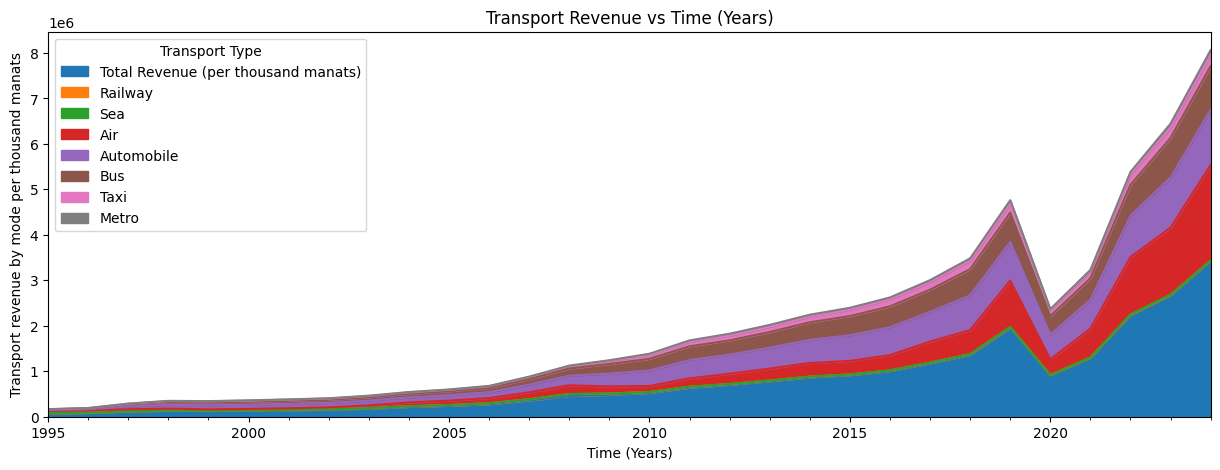

In [7]:
df1.plot(
    kind='area',
    figsize=(15, 5),
    title='Transport Revenue vs Time (Years)'
)

plt.ylabel('Transport revenue by mode per thousand manats')
plt.xlabel('Time (Years)')
plt.legend(title='Transport Type', loc='best')
plt.show()

# `df2` preprocessing

This data preprocessed on:
*   `Year` replaced as index
*   `Columns translated to English
*    Unnecessary columns dropped
*    `Year` converted to `DateTime` format.
*    `Year` sorted

In [8]:
# In just a few words, we will download, determine seperator, and load csv into dataframe!

downloadf(2)
df2 = loadf(2)
df2.head()

./datasets/data2.cs 100%[===================>]   3.77K  --.-KB/s    in 0s      


,Year,Unnamed: 1,Bütün əlaqə növləri üzrə-cəmi (min sərnişin),Şəhərlərarası (min sərnişin),avtobus (min sərnişin),dəmir yolu (min sərnişin),dəniz (min sərnişin),hava (min sərnişin),Şəhərətrafı (min sərnişin),avtobus (min sərnişin).1,dəmir yolu (min sərnişin).1,Şəhərdaxili (min sərnişin),avtobus (min sərnişin).2,minik taksiləri (min sərnişin),metro (min sərnişin),Tramvay (min sərnişin),Trolleybus (min sərnişin)
0,2022,NaN,1621129.0,34091.0,31731.0,85.0,21.0,2254.0,302092.0,297040.0,5052.0,1284946.0,992436.0,83814.0,208696.0,0.0,0.0
1,2021,NaN,1214153.0,27061.0,25831.0,79.0,18.0,1133.0,214499.0,211752.0,2747.0,972593.0,795417.0,86944.0,90232.0,0.0,0.0
2,2020,NaN,1177632.0,30769.0,29864.0,307.0,20.0,578.0,238197.0,236380.0,1817.0,908666.0,789024.0,44933.0,74709.0,0.0,0.0
3,2019,NaN,2056516.0,56409.0,52472.0,1211.0,22.0,2704.0,421169.0,418530.0,2639.0,1578938.0,1270363.0,71893.0,236682.0,0.0,0.0
4,2018,NaN,2002836.0,54620.0,51142.0,1063.0,16.0,2399.0,409702.0,407924.0,1778.0,1538514.0,1238170.0,69328.0,231016.0,0.0,0.0


In [9]:
df2 = loadf(2)  # reload doesn't affect

df2.set_index(df2['Year'], inplace=True)
df2.drop(columns=['Year', 'Unnamed: 1', 'Tramvay (min sərnişin)', 'Trolleybus (min sərnişin)'], inplace=True)

en2azcols = {
    "Bütün əlaqə növləri üzrə-cəmi (min sərnişin)": "Total (thousand passengers)",
    "Şəhərlərarası (min sərnişin)": "Intercity (thousand passengers)",
    "avtobus (min sərnişin)": "Bus – Intercity (thousand passengers)",
    "dəmir yolu (min sərnişin)": "Railway – Intercity (thousand passengers)",
    "dəniz (min sərnişin)": "Sea – Intercity (thousand passengers)",
    "hava (min sərnişin)": "Air – Intercity (thousand passengers)",

    "Şəhərətrafı (min sərnişin)": "Suburban (thousand passengers)",
    "avtobus (min sərnişin).1": "Bus – Suburban (thousand passengers)",
    "dəmir yolu (min sərnişin).1": "Railway – Suburban (thousand passengers)",

    "Şəhərdaxili (min sərnişin)": "Urban (thousand passengers)",
    "avtobus (min sərnişin).2": "Bus – Urban (thousand passengers)",
    "minik taksiləri (min sərnişin)": "Taxi – Urban (thousand passengers)",
    "metro (min sərnişin)": "Metro – Urban (thousand passengers)"
}

df2.rename(columns=en2azcols, inplace=True)
df2.index = pd.to_datetime(df2.index, format='%Y')
df2.sort_index(ascending=True, inplace=True)

df2.head()

,Total (thousand passengers),Intercity (thousand passengers),Bus – Intercity (thousand passengers),Railway – Intercity (thousand passengers),Sea – Intercity (thousand passengers),Air – Intercity (thousand passengers),Suburban (thousand passengers),Bus – Suburban (thousand passengers),Railway – Suburban (thousand passengers),Urban (thousand passengers),Bus – Urban (thousand passengers),Taxi – Urban (thousand passengers),Metro – Urban (thousand passengers)
Year,,,,,,,,,,,,,
1995-01-01,671911.0,10659.0,6908.0,2560.0,60.0,1131.0,145577.0,139182.0,6395.0,515675.0,330075.0,9844.0,150000.0
1996-01-01,721349.0,8009.0,5220.0,1499.0,39.0,1251.0,139729.0,136648.0,3081.0,573611.0,370601.0,10468.0,171598.0
1997-01-01,780810.0,11833.0,9286.0,1382.0,43.0,1122.0,191618.0,189211.0,2407.0,577359.0,382596.0,19323.0,159527.0
1998-01-01,850070.0,13564.0,11429.0,1282.0,20.0,833.0,193271.0,190266.0,3005.0,643235.0,467290.0,19782.0,143823.0
1999-01-01,854099.0,20441.0,18833.0,897.0,14.0,697.0,185801.0,182649.0,3152.0,647857.0,499568.0,21458.0,119249.0


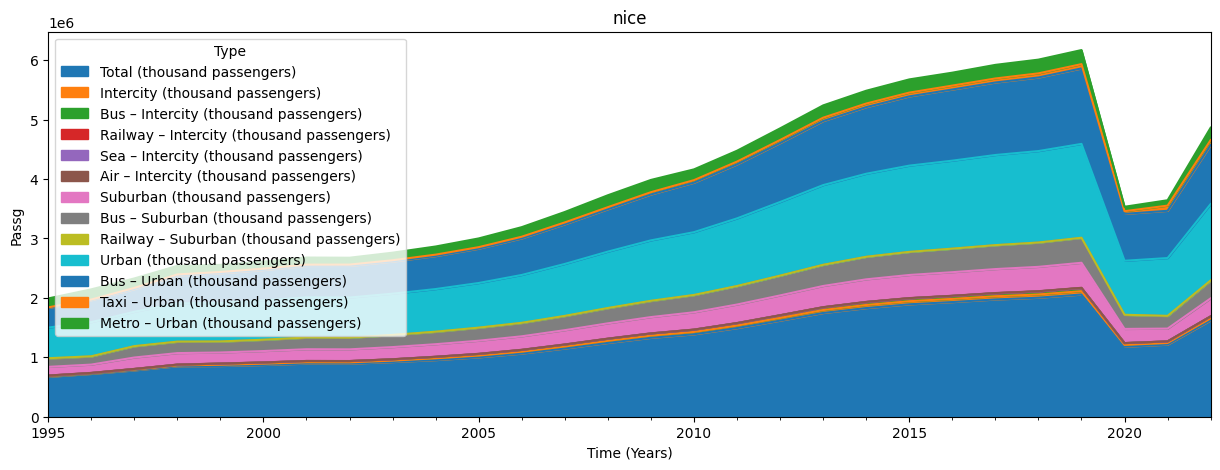

In [10]:
df2.plot(
    kind='area',
    figsize=(15, 5),
    title='nice'
)

plt.ylabel('Passg')
plt.xlabel('Time (Years)')
plt.legend(title='Type', loc='best')
plt.show()